In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


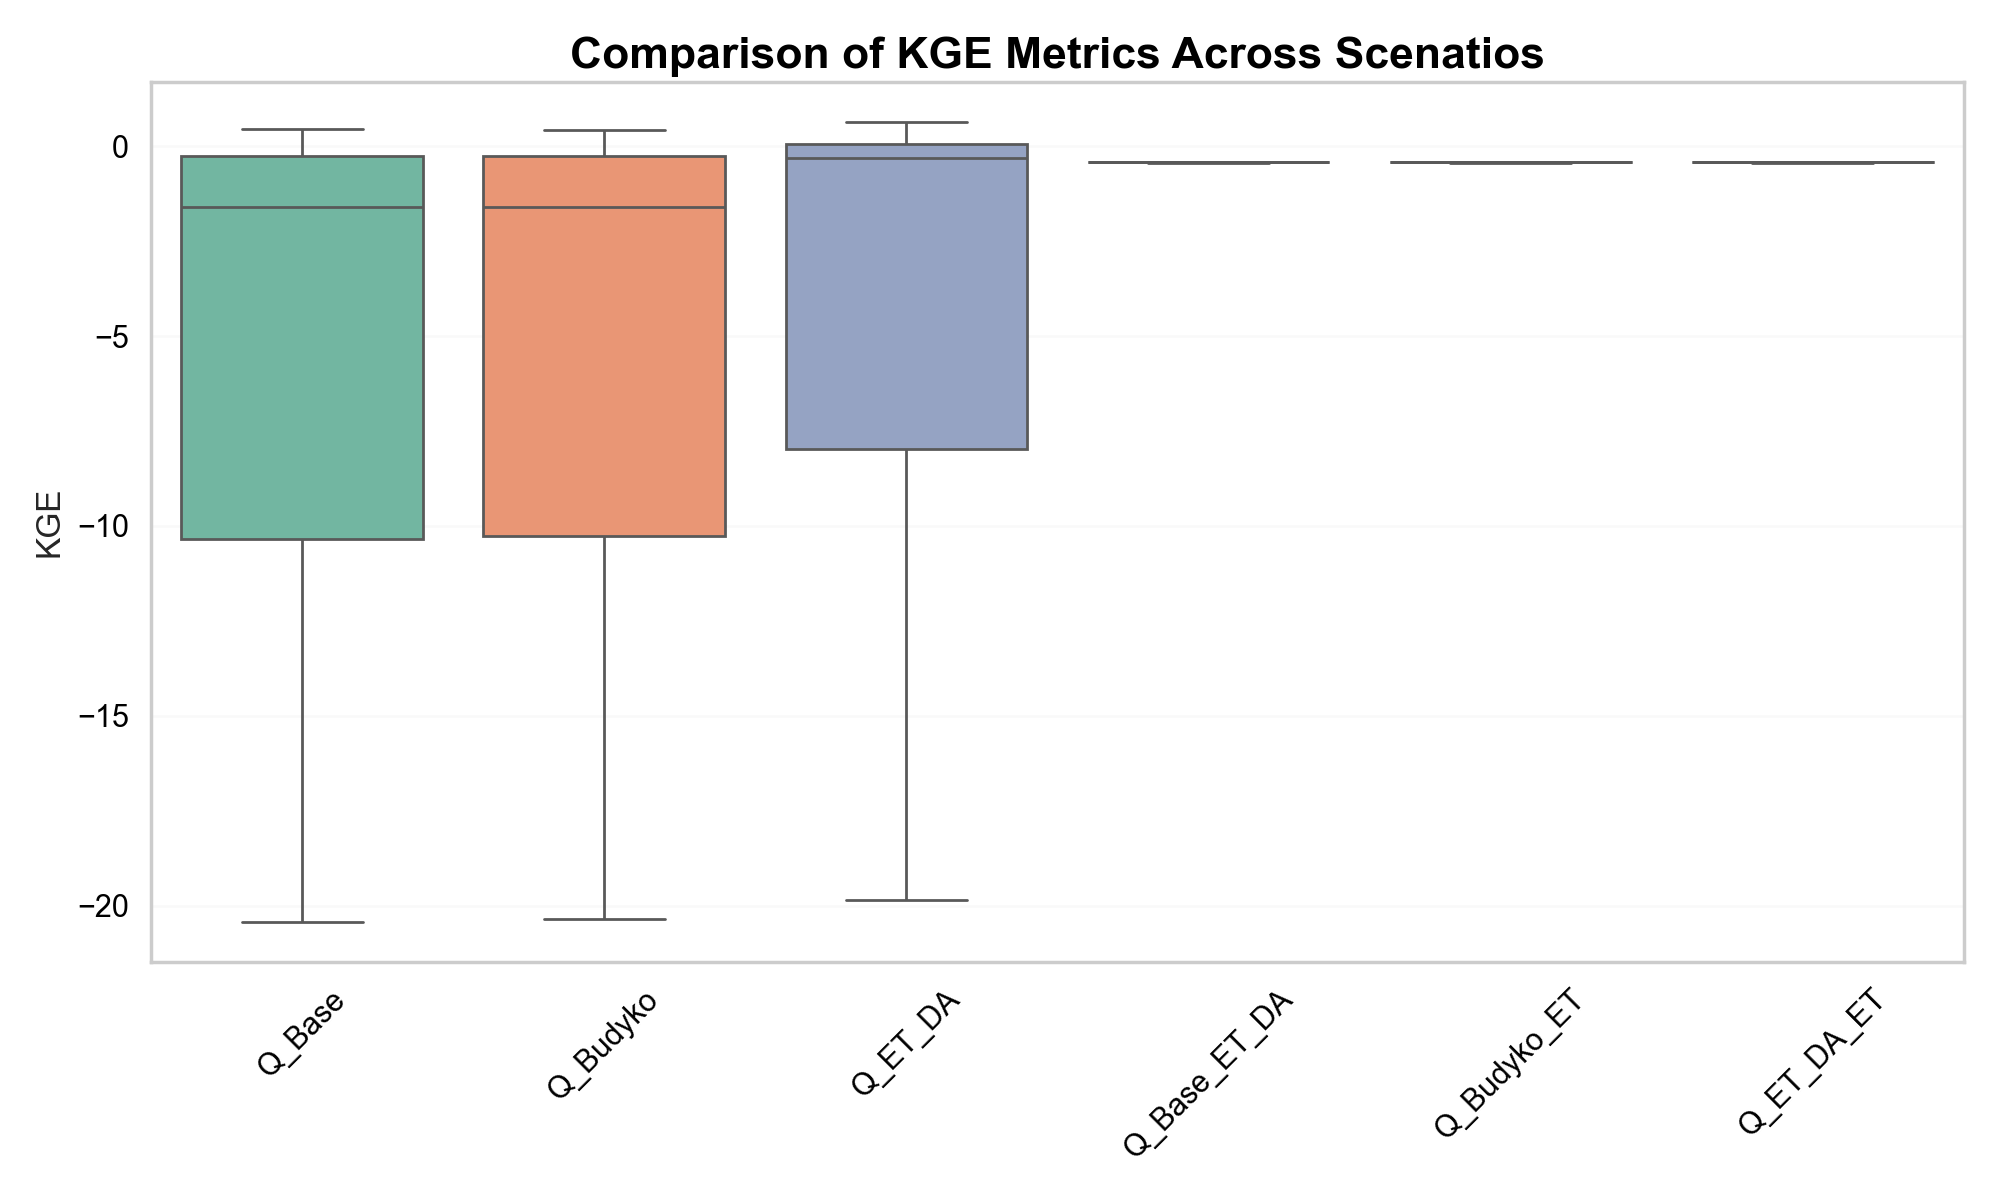

In [98]:

df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_performance_metrics.csv')
df = df.dropna()
df.set_index('basin_id', inplace=True)
df.describe()

kge_cols = ['Q_Base_Q_KGE', 'Q_B_Q_KGE', 'Q_ET_DA_Q_KGE','Q_Base_ET_KGE', 'Q_B_ET_KGE', 'Q_ET_DA_ET_KGE']

xtick_labels = ['Q_Base', 'Q_Budyko', 'Q_ET_DA', 'Q_Base_ET_DA', 'Q_Budyko_ET', 'Q_ET_DA_ET']

df_clean = df[kge_cols].replace([np.inf, -np.inf], np.nan).dropna()

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, palette="Set2", showfliers=False)
plt.xticks(ticks=range(len(xtick_labels)), labels=xtick_labels, rotation=45, fontsize=11)
plt.title("Comparison of KGE Metrics Across Scenatios", fontsize=16, fontweight='bold')
plt.ylabel("KGE", fontsize=12)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()



# hydrograph of '11522500':

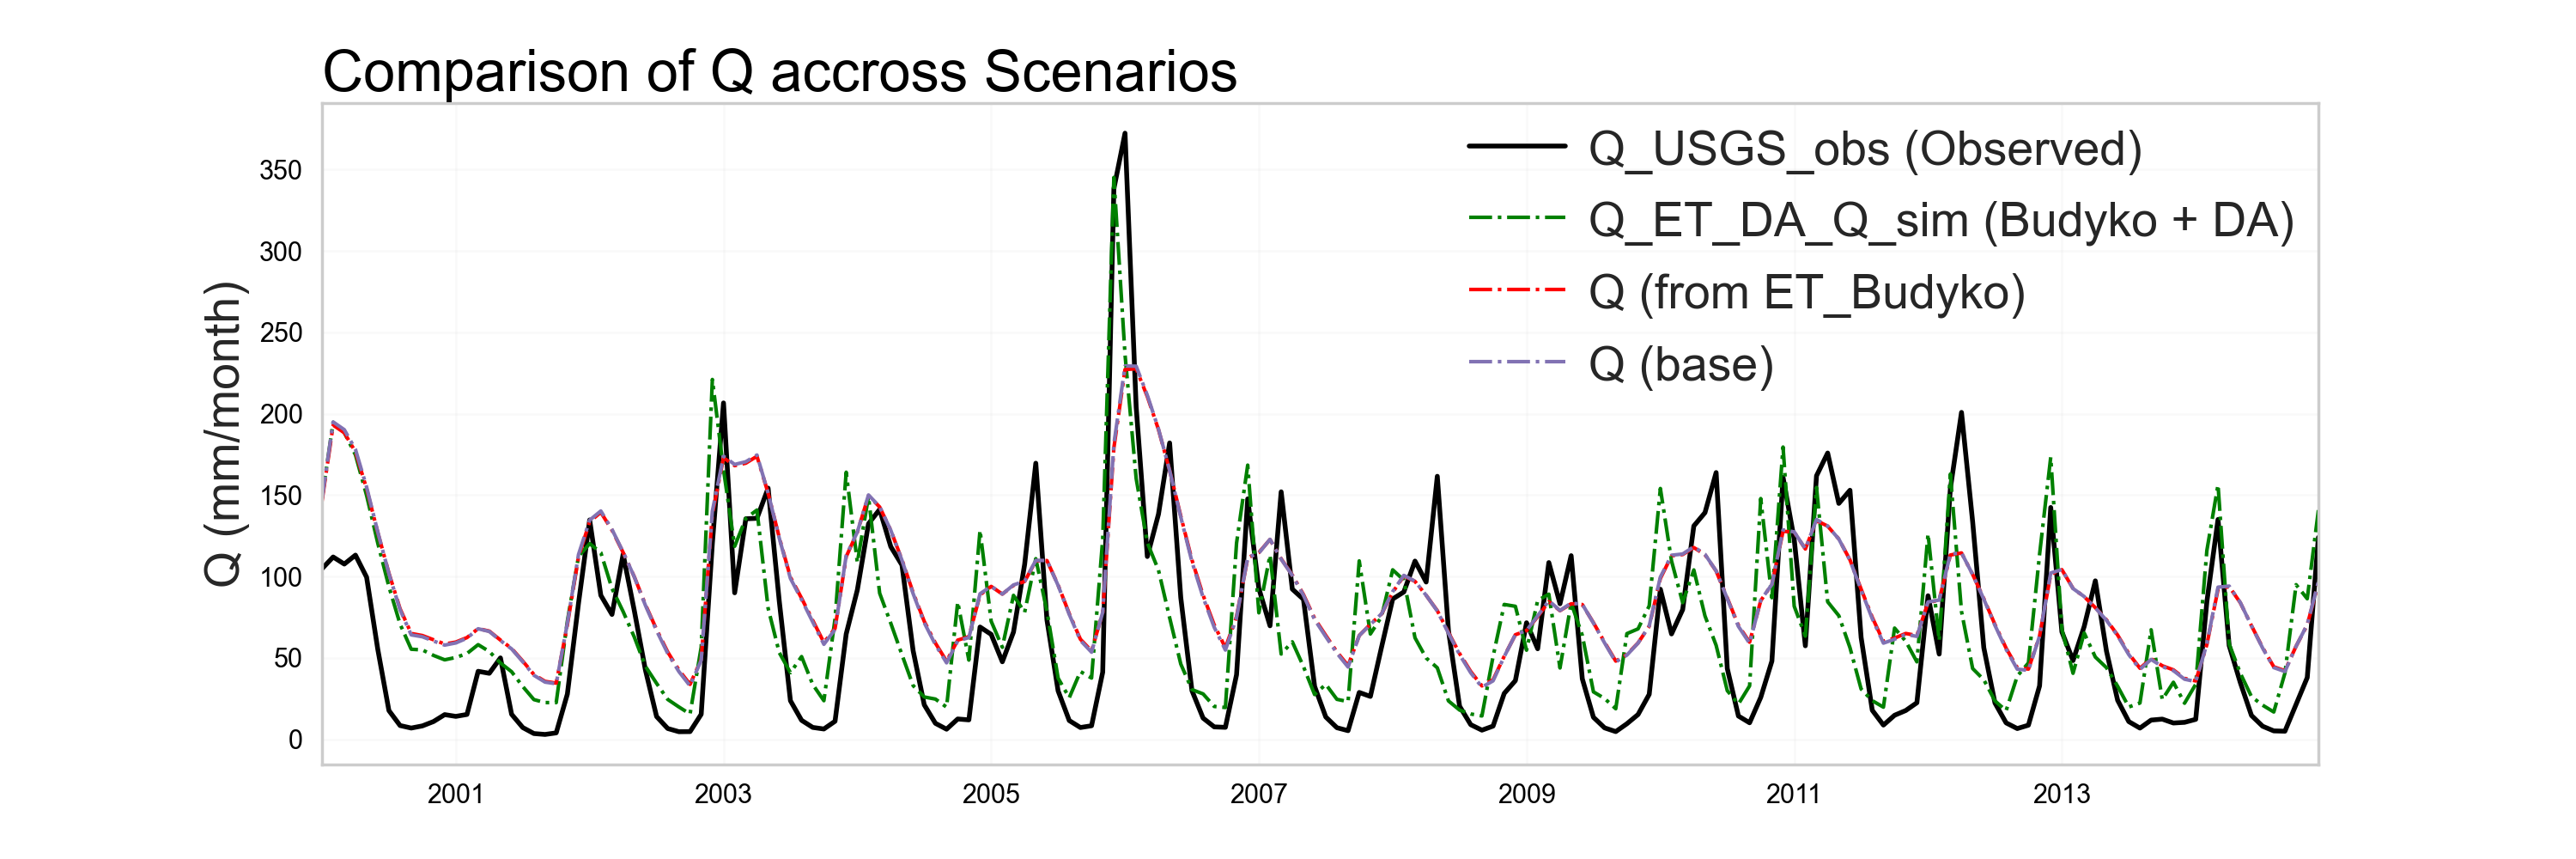

In [143]:

file_path = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\11522500_enkf_timeseries_ET_DA.feather"

if not os.path.exists(file_path):
    print("Error: Feather file not found. Check path.")
else:
    df = pd.read_feather(file_path)
    df.set_index('Date', inplace=True)
    plt.figure(figsize=(15, 5))
    df['Q_USGS_obs'].plot(label='Q_USGS_obs (Observed)', color='black', lw=2)
    df['Q_ET_DA_Q_sim'].plot(label='Q_ET_DA_Q_sim (Budyko + DA)', color='green', linestyle='-.')
    df['Q_B_Q_sim'].plot(label='Q (from ET_Budyko)', color='red', linestyle='-.')
    df['Q_Base_Q_sim'].plot(label='Q (base)', color='m', linestyle='-.')


    plt.xlabel('')
    plt.ylabel('Q (mm/month)',fontsize=20)
    plt.title('Comparison of Q accross Scenarios',fontsize=24, loc='left')
    plt.legend(fontsize=20, frameon=False)
    plt.grid(True)
    plt.show()